<a href="https://colab.research.google.com/github/tnc-br/ddf-isoscapes/blob/npr-working/probability-assignment-evals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Isoscape Evals

Notebook Purpose: Eval isoscape generation methods for our paper

Isoscape Task: Find the mean/variance of O18 ratios (as well as N15 and C13 in the future) at a particular lat/lon across Brazil.

# Setup

## Fetch Dependencies

In [1]:
!pip install rasterio fiona pykrige

## Import libraries required

In [2]:
import importlib
from datetime import datetime
import sys
import os

In [3]:
!if [ ! -d "/content/ddf_common_stub" ] ; then git clone -b test https://github.com/tnc-br/ddf_common_stub.git; fi
sys.path.append("/content/ddf_common_stub/")
import ddfimport
ddfimport.ddf_import_common()

executing checkout_branch ...
b''
main branch checked out as readonly. You may now use ddf_common imports


In [4]:
import train_variational_inference_model as tvim
import raster
import eeddf
import dataset
import fiona
import rasterio.mask
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount(raster.GDRIVE_BASE)

# Leave test_environment=True. Experiments must be done in test.
eeddf.initialize_ddf(test_environment=True)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
# Patch https://github.com/tnc-br/ddf_common/issues/72 here
import evaluation
importlib.reload(evaluation)
importlib.reload(tvim)
import evaluation

# Repartition

In [6]:
repartition = False # @param{type: "boolean"}

import pandas as pd
import numpy as np

def split_data(df, train_size=0.8, val_size=0.1, test_size=0.1, random_state=None):
  if train_size + val_size + test_size != 1:
    raise ValueError("Train, validation, and test sizes must add up to 1.")

  randomized = df.sample(frac=1, random_state=random_state)
  val_idx = int(len(randomized)*train_size)
  test_idx = int((len(randomized) - val_idx) * (val_size / (val_size+test_size)) + val_idx)

  train = randomized[:val_idx]
  val = randomized[val_idx:test_idx]
  test = randomized[test_idx:]

  if len(train) + len(val) + len(test) != len(df):
    raise Exception("Logic error")

  return train, val, test

if repartition:
    csv_file = pd.read_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_train_random_grouped_no_nans_recombined.csv')
    train, val, test = split_data(csv_file, 0.8, 0.1, 0.1, np.random.RandomState(42))
    train.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_train_random_iid_nonan.csv', index=False)
    val.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_validation_random_iid_nonan.csv', index=False)
    test.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_test_random_iid_nonan.csv', index=False)

# Data configuration

In [7]:
# REQUIREMENTS:

# 1) Column names must match features_to_standardize, features_to_passthrough
# 2) Label columns in particular must match var_label and mean_label.
#
# If you used the data ingestion notebook (ingestion.ipynb) then this
# should be set up for you already.

# TRAINING FILE PARAMS
DATABASE_DIR = raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE
TRAINING_SET_FILE = 'canonical/12_16_filtered_train_random_iid_nonan.csv' #@param
VALIDATION_SET_FILE = 'canonical/12_16_filtered_validation_random_iid_nonan.csv' #@param
TEST_SET_FILE = 'canonical/12_16_filtered_test_random_iid_nonan.csv' #@param

# EVAL FILE PARAMS
EVAL_DATASET = 'canonical/12_16_filtered_test_random_iid_nonan.csv' #@param
#ORIGINAL_DATASET = 'canonical/2023_07_27_Results_google_utf8_latlonadded.csv' #@param
ORIGINAL_DATASET = 'canonical/12_16_ungrouped.csv' #@param


fileset = {
    'TRAIN' : os.path.join(DATABASE_DIR, TRAINING_SET_FILE),
    'TEST' : os.path.join(DATABASE_DIR, TEST_SET_FILE),
    'VALIDATION' : os.path.join(DATABASE_DIR, VALIDATION_SET_FILE),
    'EVAL' : os.path.join(DATABASE_DIR, EVAL_DATASET),
    'ORIGINAL' : os.path.join(DATABASE_DIR, ORIGINAL_DATASET)
}

def prepare_dataset(params: tvim.VIModelTrainingParams, files: dict) -> dataset.ScaledPartitions:
  # Prepared columns not in the original input-- these are engineered features
  # that we believe include strong signals, stored as geotiffs
  potentially_extra_columns = [
      "brisoscape_mean_ISORIX",
      "d13C_cel_mean",
      "d13C_cel_var",
      "ordinary_kriging_linear_d18O_predicted_mean",
      "ordinary_kriging_linear_d18O_predicted_variance",
  ]

  #Load the geotiff it the params request it.
  extra_columns_from_geotiffs = {}
  for feature in params.features_to_passthrough + params.features_to_standardize:
      if feature in potentially_extra_columns:
          extra_columns_from_geotiffs[feature] = raster.column_name_to_geotiff_fn[feature]()

  return dataset.load_and_scale(
      files,
      params.mean_label,
      params.var_label,
      params.features_to_passthrough,
      [],
      params.features_to_standardize,
      extra_columns_from_geotiffs)

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/bra_adm_ibge_2020_shp.zip') as shp:
  BRAZIL_SHP_MASK = [feature["geometry"] for feature in shp]

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/Amazon Biome.zip/data/commondata/data0') as shp:
  AMAZON_SHP_MASK = [feature["geometry"] for feature in shp]

# Load these lazily later from the first generated isoscapes

def display_brazil(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, BRAZIL_SHP_MASK, crop=False)
    out_meta = src.meta
    brazil_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, brazil_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

def display_amazon(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, AMAZON_SHP_MASK, crop=False)
    out_meta = src.meta
    amazon_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, amazon_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

# External Isoscape (Autokrige)

In [69]:
means_raster = raster.load_raster(f'{DATABASE_DIR}/../amazon_rasters/gabi_iso_d18O_wood_map_random_iid_split.tiff')
vars_raster = raster.load_raster(f'{DATABASE_DIR}/../amazon_rasters/gabi_iso_d18O_wood_map_random_iid_split_var.tiff')

Driver: GTiff/GeoTIFF
Size is 1476 x 1024 x 1
Projection is PROJCS["SIRGAS 2000 / Brazil Polyconic",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4674"]],PROJECTION["Polyconic"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-54],PARAMETER["false_easting",5000000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5880"]]
Origin = (-73.98318215899995, 5.269580833000035)
Pixel Size = (0.02072077522493222, -0.021417577473632765)
Driver: GTiff/GeoTIFF
Size is 1476 x 1024 x 1
Projection is PROJCS["SIRGAS 2000 / Brazil Polyconic",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",

In [70]:
!head {DATABASE_DIR}{EVAL_DATASET}

Unnamed: 0,Code,lat,long,d13C_foliar,d15N_foliar,d15N_soil,VPD,RH,PET,DEM,PA,Mean Annual Temperature,Mean Annual Precipitation,Iso_Oxi_Stack_mean_TERZER,brisoscape_mean_ISORIX,d13C_cel_mean,d13C_cel_var,ordinary_kriging_linear_d18O_predicted_mean,ordinary_kriging_linear_d18O_predicted_variance,isoscape_fullmodel_d18O_prec_REGRESSION,d18O_cel_count,d18O_cel_mean,d18O_cel_variance
165,mad710,-8.625,-62.852,-27.93915939,5.142177105,8.599728584,0.61833,0.81981,91.075,157,994.23041,25.50833,2311,-4.84743,-4.827298164,-26.73980459,0.1879344384,25.10909423,0.8690671381,-4.849006335,5,26.446,1.10123
242,mad84,-3.3983972,-54.973982,-27.4411602,5.768527985,9.537585258,0.645,0.81744,97.93333,139,996.36792,26.0,1840,-3.56381,-3.536934853,-26.48528798,0.1190467775,26.12486882,0.7889210593,-3.4262927373250327,5,26.22,0.5327500000000008
1,mad1,-3.995544837,-57.58927257,-28.99231529,4.894455433,9.003260612,0.85167,0.77358,99.99167,61,1005.67358,27.16667,2273,-3.78967,-3.789665222,-27.92172496,0.033720

In [71]:

res = evaluation.evaluate(means_raster, vars_raster,
                  pd.read_csv(f'{DATABASE_DIR}{ORIGINAL_DATASET}'),
                   ['d18O_cel'],
                  eval_dataset=pd.read_csv(f'{DATABASE_DIR}{EVAL_DATASET}'),
                  mean_label="d18O_cel_mean",
                  var_label="d18O_cel_variance",
                  sample_size_per_location=5,
                  precision_target=0.95,
                  recall_target=None,
                  start_max_fraud_radius=6,
                  end_max_fraud_radius=3000,
                  radius_pace=100,
                  trusted_buffer_radius=5)

Text(0.5, 0, 'Simulated Fraud Radius (km)')

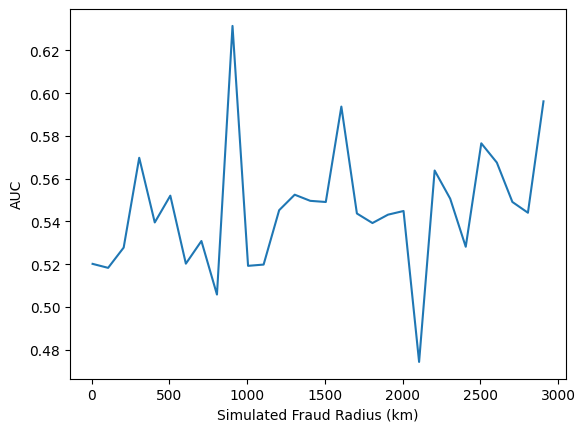

In [72]:
#x = np.array([x['radius'] for x in res.rmse['per_radius_eval']])
#y = np.array([x['auc'] for x in res.rmse['per_radius_eval']])
x = np.array(list(res.auc_scores.keys()))
y = np.array(list(res.auc_scores.values()))
plt.plot(x, y, label='AUC')
if False:
    spl = UnivariateSpline(x, y, s=1)
    x_smooth = np.linspace(x.min(), x.max(), 500)
    y_smooth = spl(x_smooth)
    plt.plot(x_smooth, y_smooth, 'g-', lw=3, label='Smoothed')
plt.ylabel('AUC')
plt.xlabel('Simulated Fraud Radius (km)')

In [73]:
res.rmse

{'mean_rmse': 1.1800431907236404,
 'var_rmse': 1.3382402919081664,
 'overall_rmse': 1.2591417413159034}

# Non-VI Models

## Ordinary Kriging

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/00_ordinary.html

In [ ]:
import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-okrige-2025-04-18-2", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    min_steps=-1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "ordinary_kriging", "all_standardized", "gaussian_variogram", "rev5"], #@param
    n_cv_folds=None,
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")


In [ ]:
data = prepare_dataset(params, fileset)

In [ ]:
import pandas as pd
import numpy as np
import raster
import generate_isoscape
from sklearn.metrics import mean_squared_error

raw_train = pd.read_csv(fileset['TRAIN'])

In [ ]:
def run_ordinary_kriging(**kwargs):
  # Not enough data to properly fit a Gaussian variogram
  ok = OrdinaryKriging(data.train.X['lat'], data.train.X['long'], data.train.Y['d18O_cel_mean'], **kwargs)

  min_long = min(data.train.X['long'])
  max_long = max(data.train.X['long'])
  min_lat = min(data.train.X['lat'])
  max_lat = max(data.train.X['lat'])

  # Predict the isotope values on the range of lattitude and longitude values
  # within the bounds of our VPD geotiff (should be Brazil-shaped), then save
  # for qualitative eval / display
  isoscape_long_values =  np.linspace(min_long, max_long, params.resolution_x)
  isoscape_lat_values = np.linspace(min_lat, max_lat, params.resolution_y)

  means, variances  = ok.execute("grid", isoscape_long_values,
                                  isoscape_lat_values)
  ok.print_statistics()

  arbitrary_geotiff = raster.vapor_pressure_deficit_geotiff()
  base_bounds = raster.get_extent(arbitrary_geotiff.gdal_dataset)
  final_bounds = raster.create_bounds_from_res(params.resolution_x, params.resolution_y, base_bounds)

  all_predictions = np.ma.masked_array([means, variances], mask=[np.isnan(means), np.isnan(variances)]) # raster, lat, lon
  all_predictions = np.transpose(all_predictions, axes=[1, 2, 0]) # lat, lon, raster

  generate_isoscape.save_numpy_to_geotiff(final_bounds, all_predictions, ISOSCAPE_SAVE_LOCATION)

  # Quantitative Eval Metrics
  test_pred_means, test_pred_vars  = ok.execute("points", data.test.X['long'],
                                  data.test.X['lat'])
  test_ground_means = data.test.Y[params.mean_label]
  test_ground_vars = data.test.Y[params.var_label]
  print(f'Means RMSE: {np.sqrt(mean_squared_error(test_ground_means, test_pred_means))}')
  print(f'Variances RMSE: {np.sqrt(mean_squared_error(test_ground_vars, test_pred_vars))}')



In [ ]:
# Not enough data for a gaussian variogram (we only use the 'train' split)
run_ordinary_kriging(variogram_model='linear')

Q1 = None
Q2 = None
cR = None
Means RMSE: 1.3465345306384018
Variances RMSE: 0.7519736955498336


In [ ]:
display_brazil(0) # Means

In [ ]:
display_amazon(0) # Means

In [ ]:
EVAL_ONLY = True
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


In [ ]:
params.tags

['author:npr',
 'ordinary_kriging',
 'all_standardized',
 'gaussian_variogram',
 'rev5']

## Universal Kriging w/ Spatial Drift Only

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/01_universal.html

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-ukrige-2025-04-18-1", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    min_steps=-1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "universal_kriging", "all_standardized", "linear_variogram", "rev3"], #@param
    n_cv_folds=None,
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")


In [ ]:
data = prepare_dataset(params, fileset)

Driver: GTiff/GeoTIFF
Size is 541 x 467 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-73.922043, 5.233124)
Pixel Size = (0.08333, -0.08333)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0, 4.5)
Pixel Size = (0.16666668085106384, -0.1666666513761468)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTH

In [ ]:
import pandas as pd
import numpy as np
import raster
import pykrige.kriging_tools as kt
import generate_isoscape
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error
raw_train = pd.read_csv(fileset['TRAIN'])

In [ ]:
def run_universal_kriging(**kwargs):
  uk = UniversalKriging(data.train.X['lat'], data.train.X['long'], data.train.Y['d18O_cel_mean'], **kwargs)
  min_long = min(data.train.X['long'])
  max_long = max(data.train.X['long'])
  min_lat = min(data.train.X['lat'])
  max_lat = max(data.train.X['lat'])

  # Predict the isotope values on the range of lattitude and longitude values
  # within the bounds of our VPD geotiff (should be Brazil-shaped), then save
  # for qualitative eval / display
  isoscape_long_values =  np.linspace(min_long, max_long, params.resolution_x)
  isoscape_lat_values = np.linspace(min_lat, max_lat, params.resolution_y)
  means, variances  = uk.execute("grid", isoscape_long_values,
                                  isoscape_lat_values)
  uk.print_statistics()

  arbitrary_geotiff = raster.vapor_pressure_deficit_geotiff()
  base_bounds = raster.get_extent(arbitrary_geotiff.gdal_dataset)
  final_bounds = raster.create_bounds_from_res(params.resolution_x, params.resolution_y, base_bounds)

  all_predictions = np.ma.masked_array([means, variances], mask=[np.isnan(means), np.isnan(variances)]) # raster, lat, lon
  all_predictions = np.transpose(all_predictions, axes=[1, 2, 0]) # lat, lon, raster

  generate_isoscape.save_numpy_to_geotiff(final_bounds, all_predictions, ISOSCAPE_SAVE_LOCATION)

  # Quantitative Eval Metrics
  test_pred_means, test_pred_vars  = uk.execute("points", data.test.X['long'],
                                  data.test.X['lat'])
  test_ground_means = data.test.Y[params.mean_label]
  test_ground_vars = data.test.Y[params.var_label]
  print(f'Means RMSE: {np.sqrt(mean_squared_error(test_ground_means, test_pred_means))}')
  print(f'Variances RMSE: {np.sqrt(mean_squared_error(test_ground_vars, test_pred_vars))}')


In [ ]:
run_universal_kriging(variogram_model='gaussian', drift_terms=['regional_linear'])

Q1 = 0.2382429935229234
Q2 = 1.2573228101735001
cR = 1.516487672064444
Means RMSE: 1.4910069942128807
Variances RMSE: 0.7214404419209571


In [ ]:
display_brazil(0)

In [ ]:
EVAL_ONLY = True
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


## Universal Kriging w/ Drift d18O~MAP+d13C_foliar

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/01_universal.html

In [359]:
params = tvim.VIModelTrainingParams(
    training_id = "ukrige-cov-2025-06-13-1", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    min_steps=-1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['Mean Annual Precipitation', 'd13C_cel_mean'], #@param
    features_to_passthrough = ['lat', 'long'], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "universal_kriging", "all_standardized", "linear_variogram", "rev3"], #@param
    n_cv_folds=None,
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")


In [360]:
data = prepare_dataset(params, fileset)

In [361]:
import pandas as pd
import numpy as np
import raster
import pykrige.kriging_tools as kt
from pykrige.uk import UniversalKriging
import generate_isoscape
from sklearn.metrics import mean_squared_error
raw_train = pd.read_csv(fileset['TRAIN'])

In [362]:

def run_universal_kriging(**kwargs):
  uk = UniversalKriging(data.train.X['lat'], data.train.X['long'], data.train.Y['d18O_cel_mean'],
                        specified_drift=[data.train.X['Mean Annual Precipitation'].tolist(),
                                         data.train.X['d13C_cel_mean'].tolist()],
                        **kwargs)
  min_long = min(data.train.X['long'])
  max_long = max(data.train.X['long'])
  min_lat = min(data.train.X['lat'])
  max_lat = max(data.train.X['lat'])

  # Predict the isotope values on the range of lattitude and longitude values
  # within the bounds of our VPD geotiff (should be Brazil-shaped), then save
  # for qualitative eval / display
  isoscape_long_values =  np.linspace(min_long, max_long, params.resolution_x)
  isoscape_lat_values = np.linspace(min_lat, max_lat, params.resolution_y)
  if False:
    means, variances  = uk.execute("grid", isoscape_long_values,
                                    isoscape_lat_values)
  uk.print_statistics()

  arbitrary_geotiff = raster.vapor_pressure_deficit_geotiff()
  base_bounds = raster.get_extent(arbitrary_geotiff.gdal_dataset)
  final_bounds = raster.create_bounds_from_res(params.resolution_x, params.resolution_y, base_bounds)

  if False:
    all_predictions = np.ma.masked_array([means, variances], mask=[np.isnan(means), np.isnan(variances)]) # raster, lat, lon
    all_predictions = np.transpose(all_predictions, axes=[1, 2, 0]) # lat, lon, raster

    generate_isoscape.save_numpy_to_geotiff(final_bounds, all_predictions, ISOSCAPE_SAVE_LOCATION)

  # Quantitative Eval Metrics
  test_pred_means, test_pred_vars  = uk.execute("points", data.test.X['long'],
                                  data.test.X['lat'], specified_drift_arrays=[
                                      np.array(data.test.X['Mean Annual Precipitation'].tolist()), np.array(data.test.X['d13C_cel_mean'])])
  test_ground_means = data.test.Y[params.mean_label]
  test_ground_vars = data.test.Y[params.var_label]
  print(f'Means RMSE: {np.sqrt(mean_squared_error(test_ground_means, test_pred_means))}')
  print(f'Variances RMSE: {np.sqrt(mean_squared_error(test_ground_vars, test_pred_vars))}')

In [365]:
run_universal_kriging(variogram_model='linear', drift_terms=['regional_linear', 'specified'])

Q1 = 0.027412402334126403
Q2 = 1.2025884294696838
cR = 1.8202238457444921
Means RMSE: 1.2532417825399071
Variances RMSE: 1.3873197425276178


## Regression Kriging

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/07_regression_kriging2d.html

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-rkrige-2025-01-31-2", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    min_steps=-1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = ['lat', 'long'], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "regression_kriging", "all_standardized", "rev2", "krige_type:regression", "variogram:gaussian", "n_estimators:100", "max_depth:20", "regression_strategy:gradientboosting"], #@param
    n_cv_folds = None
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")

In [ ]:
import pandas as pd
import numpy as np
import raster
from numpy.typing import NDArray
from typing import Tuple, List

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import generate_isoscape
import model

from pykrige.rk import RegressionKriging


def run_regression_kriging(regression_model, regression_kwargs, krige_kwargs):
  data = prepare_dataset(params, fileset)
  raw_train = pd.read_csv(fileset['TRAIN']).dropna()
  raw_val = pd.read_csv(fileset['VALIDATION']).dropna()

  svr_model = SVR(C=0.1, gamma="auto")
  rf_model = RandomForestRegressor(n_estimators=1000)
  lr_model = LinearRegression(copy_X=True, fit_intercept=True)
  gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=20)

  models = [svr_model, rf_model, lr_model]

  train_features = params.features_to_standardize + params.features_to_passthrough
  train_features_nolatlon = list(train_features)
  train_features_nolatlon.remove('lat')
  train_features_nolatlon.remove('long')

  p_train = pd.concat((data.train.X[train_features_nolatlon], data.val.X[train_features_nolatlon],), join='inner')
  x_train = np.concatenate((np.array(tuple(zip(raw_train['lat'], raw_train['long']))), np.array(tuple(zip(raw_val['lat'], raw_val['long'])))))
  target_train = pd.concat((raw_train[params.mean_label], raw_val[params.mean_label],), join='inner')


  rk = RegressionKriging(regression_model=regression_model(**regression_kwargs), **krige_kwargs)
  # Why do I call .to_numpy() here?
  # to_numpy() removes feature names, which ColumnTransformer.transform() strips
  # in predict_on_batch(). If trained with feature names but inference is run
  # without, a long list of warnings will be printed and isoscape generation will
  # be slower.
  rk.fit(p_train.to_numpy(), x_train, target_train)


  class DDFRegressionKrigingModel(model.Model):
    # #@override
    def __init__(self, rk: RegressionKriging, training_cols: List[str]):
      self.rk = rk
      self.training_cols = training_cols

    # #@override
    def predict_on_batch(self, X: pd.DataFrame) -> NDArray[np.float32]:
      #TODO(ruru): Maybe our isoscape generator should standardize the features in features_to_standardize here as well
      #TODO: The scaling step appears to add some time. This might be a good target for future performance efforts.
      XT = data.feature_scaler.transform(X)
      latindex = X.columns.get_loc('lat')
      longindex = X.columns.get_loc('long')
      x = X[['lat', 'long']].to_numpy()
      p = np.delete(XT, [latindex, longindex],axis=1)
      means = self.rk.predict(p, x)
      return np.array([means, np.zeros(means.shape)]).T

    # #@override
    def training_column_names(self) -> List[str]:
      return ['lat', 'long'] + self.training_cols


  rkm = DDFRegressionKrigingModel(rk=rk, training_cols=train_features_nolatlon)



  # Quantitative Eval Metrics
  test_preds = rkm.predict_on_batch(data.test.X)
  test_pred_means = test_preds[:,0]
  test_ground_means = data.test.Y[params.mean_label]
  print(f'Means RMSE: {np.sqrt(mean_squared_error(test_ground_means, test_pred_means))}')


  #generate_isoscape.generate_isoscapes_from_variational_model(rkm, 1024, 1024, ISOSCAPE_SAVE_LOCATION)


In [ ]:
import random
random.seed(42)
import numpy as np
np.random.seed(42)
run_regression_kriging(GradientBoostingRegressor, {'n_estimators':100, 'max_depth':20}, {'method': 'ordinary', 'variogram_model':'linear', 'drift_terms':[]})

Finished learning regression model
Finished kriging residuals
Means RMSE: 1.5722274795825761


In [ ]:
display_brazil(0)

In [ ]:
display_amazon(0)

In [ ]:
EVAL_ONLY = True
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


# Variational Inference + DNN

In [ ]:
# Convenience links:
# Paper: https://braintex.goog/project/6509cbf324c22900a893d018
# Experiment list: https://docs.google.com/spreadsheets/d/1QUGvdUkkYCnflTytaYelMsbzGjhvR0U_HBkRdDUdeGM/edit?gid=1787854098#gid=1787854098
#

In [8]:
import tensorflow as tf

In [9]:
tf.keras.utils.set_random_seed(18731)


In [10]:
params = tvim.VIModelTrainingParams(
    training_id = "2025-06-13-vinn-random-1", #@param
    num_epochs = 5000, #@param
    num_layers = 2, #@param
    min_steps = 100, #@param,
    num_nodes_per_layer = 20, #@param
    training_batch_size = 5, #@param
    learning_rate = 0.0001, #@param
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = 100, #@param
    double_sided_kl = False, #@param
    kl_num_samples_from_pred_dist = 15, #@param
    dropout_rate = 0, #@param
    activation_func = "relu", #@param
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "ViNN", "rev2"], #@param
    foo = "bar",
    n_cv_folds=None
)

eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)

MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE.lstrip('/'), params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")

# Train the model

/usr/local/lib/python3.11/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Driver: GTiff/GeoTIFF
Size is 541 x 467 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-73.922043, 5.233124)
Pixel Size = (0.08333, -0.08333)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0, 4.5)
Pixel Size = (0.16666668085106384, -0.1666666513761468)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTH

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20)        │        340 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20)        │        420 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ var_output (Dense)  │ (None, 1)         │         21 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_output (Dense) │ (None, 1)         │         21 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1)         │          0 │ var_output[0][0]  │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1)         │          0 │ mean_output[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 1)         │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 1)         │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softplus_layer      │ (None, 1)         │          0 │ cast[0][0]        │
│ (SoftplusLayer)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ cast_1[0][0],     │
│ (Concatenate)       │                   │            │ softplus_layer[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 802 (3.13 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/5000


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.0607 - val_loss: 2.2773
Epoch 2/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.8208 - val_loss: 1.7669
Epoch 3/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6879 - val_loss: 2.3329
Epoch 4/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5316 - val_loss: 1.7150
Epoch 5/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9344 - val_loss: 1.6610
Epoch 6/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2112 - val_loss: 1.8517
Epoch 7/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3698 - val_loss: 1.6565
Epoch 8/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7967 - val_loss: 1.8211
Epoch 9/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1189 - val_loss: 1.7807
Epoch 10/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0539 - val_loss: 1.9103
Epoch 11/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0927 - val_loss: 1.9977
Epoch 12/5000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2

/tmp/ddf_common/model.py:354: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0, 10))


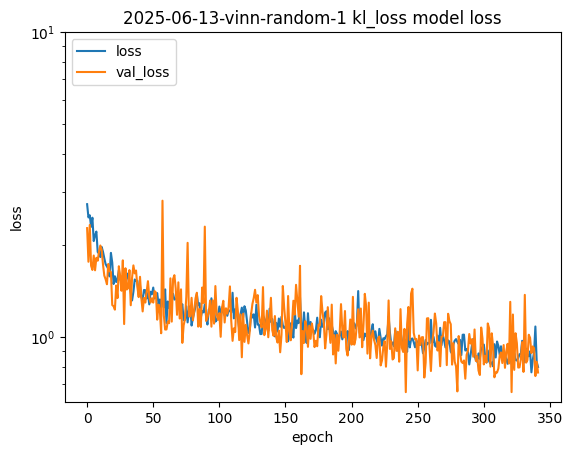

Val loss: 0.6602726578712463
Train loss: 0.9762994050979614
Test loss: 1.0790711641311646
dO18 RMSE: {'mean_rmse': np.float64(1.1980097186150682), 'var_rmse': np.float64(1.282768171775338)}
Driver: GTiff/GeoTIFF
Size is 941 x 937 x 12
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.04166666666665718, -0.04166666666667143)
Driver: GTiff/GeoTIFF
Size is 941 x 937 x 12
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORIT

100%|██████████| 1024/1024 [01:40<00:00, 10.18it/s]


Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


In [11]:
EVAL_ONLY = False #@param{type:'boolean'}
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY, enable_fraud_detection_eval=True)

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
import pickle

In [ ]:
with open(raster.GDRIVE_BASE + "/MyDrive/brazil_random_split_results.pkl", "wb") as f:
    pickle.dump(res, f)

In [ ]:
x = np.array([x['radius'] for x in res.rmse['per_radius_eval']])
y = np.array([x['auc'] for x in res.rmse['per_radius_eval']])
plt.plot(x, y, label='AUC')
if False:
    spl = UnivariateSpline(x, y, s=1)
    x_smooth = np.linspace(x.min(), x.max(), 500)
    y_smooth = spl(x_smooth)
    plt.plot(x_smooth, y_smooth, 'g-', lw=3, label='Smoothed')
plt.ylabel('AUC')
plt.xlabel('Simulated Fraud Radius (km)')

In [ ]:
from scipy.interpolate import UnivariateSpline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


for result in res.rmse['per_radius_eval']:
    if result['radius'] == 506:
        print(f'AUC={result["auc"]}')
        x= np.array(result['pr_curve']['recall'])
        y= np.array(result['pr_curve']['precision'])
        plt.plot(x,y, label='Fraud Detection at 506km')
        spl = UnivariateSpline(x[::-1], y[::-1], s=1)
        x_smooth = np.linspace(x.min(), x.max(), 500)
        y_smooth = spl(x_smooth)
        plt.plot(x_smooth, y_smooth, 'g-', lw=3, label='Smoothed')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.legend()

In [ ]:
res

EvalResults(rmse={'mean_rmse': 1.2388650984847818, 'var_rmse': 1.2856376259669902, 'overall_rmse': 1.2622513622258862, 'per_radius_eval': [{'radius': 6, 'auc': np.float64(0.4806492362828935), 'p_value': np.float64(0.00650560455856386), 'precision_target': np.float64(0.6666666666666666), 'recall_target': np.float64(0.08), 'pr_curve': {'precision': [0.5, 0.4897959183673469, 0.5, 0.48936170212765956, 0.4782608695652174, 0.4888888888888889, 0.5, 0.5116279069767442, 0.5, 0.5121951219512195, 0.5, 0.48717948717948717, 0.47368421052631576, 0.4594594594594595, 0.4722222222222222, 0.4857142857142857, 0.5, 0.48484848484848486, 0.46875, 0.4838709677419355, 0.4666666666666667, 0.4827586206896552, 0.5, 0.48148148148148145, 0.46153846153846156, 0.48, 0.4583333333333333, 0.43478260869565216, 0.45454545454545453, 0.47619047619047616, 0.5, 0.5263157894736842, 0.5, 0.5294117647058824, 0.5, 0.5333333333333333, 0.5, 0.46153846153846156, 0.5, 0.5454545454545454, 0.5, 0.4444444444444444, 0.5, 0.4285714285714

In [ ]:
import evaluation

ModuleNotFoundError: No module named 'evaluation'

# Optional Rendering

In [12]:
ISOSCAPE_SAVE_LOCATION

'/content/gdrive/MyDrive/amazon_rainforest_files/amazon_rasters/2025-06-13-vinn-random-1.tiff'

In [ ]:
from matplotlib import rc
rc('animation', html='jshtml')

means_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=0)
raster.animate(means_isoscape,  1, 1)

In [ ]:
vars_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=1)
raster.animate(vars_isoscape,  1, 1)